# Credit Card Fraud Detection - Preprocessing (v2)

**Changes from v1:**
1. `user_mean_amt` / `user_std_amt` are now **causal expanding** statistics. At row N
   they only use that user's transactions strictly *before* N. v1 used a single per-user
   mean over all years, which leaked future (test-year) info into training.
2. `tx_year` is no longer a model feature. It rides along in `features.csv` so NB3 can
   split on it, but is dropped from the model input.
3. Heavy-tailed features (`time_since_last_tx`, `amount_vs_user_mean`) are clipped so
   the linear / neural-net models don't blow up after scaling.

Run order: this notebook -> 03_training_v2.ipynb


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path('/teamspace/studios/this_studio/Dataset')
OUT_DIR  = Path('/teamspace/studios/this_studio/outputs')
OUT_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 2. Load Raw Data

In [2]:
print('Loading raw data...')

transactions = pd.read_csv(DATA_DIR / 'transactions_data.csv')
users        = pd.read_csv(DATA_DIR / 'users_data.csv')
cards        = pd.read_csv(DATA_DIR / 'cards_data.csv')

with open(DATA_DIR / 'mcc_codes.json', 'r') as f:
    mcc_codes = json.load(f)

print('Loading fraud labels (1-2 min)...')
with open(DATA_DIR / 'train_fraud_labels.json', 'r') as f:
    data = json.load(f)
fraud_labels = data['target']

print(f'Transactions : {len(transactions):,}')
print(f'Users        : {len(users):,}')
print(f'Cards        : {len(cards):,}')
print(f'Fraud labels : {len(fraud_labels):,}')

Loading raw data...
Loading fraud labels (1-2 min)...
Transactions : 13,305,915
Users        : 2,000
Cards        : 6,146
Fraud labels : 8,914,963


## 3. Merge Fraud Labels

In [3]:
labels_df = pd.DataFrame(list(fraud_labels.items()), columns=['id', 'is_fraud'])
labels_df['id']    = labels_df['id'].astype(str).str.strip()
transactions['id'] = transactions['id'].astype(str).str.strip()

df = transactions.merge(labels_df, on='id', how='inner')

print(f'Rows after merge : {len(df):,}')
print(df['is_fraud'].value_counts())

Rows after merge : 8,914,963
is_fraud
No     8901631
Yes      13332
Name: count, dtype: int64


## 4. Merge User and Card Data

In [4]:
users['id']     = users['id'].astype(str)
cards['id']     = cards['id'].astype(str)
df['client_id'] = df['client_id'].astype(str)
df['card_id']   = df['card_id'].astype(str)

df = df.merge(users.rename(columns={'id': 'client_id'}), on='client_id', how='left')
df = df.merge(cards.rename(columns={'id': 'card_id'}), on='card_id', how='left', suffixes=('', '_card'))

print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
df.head(3)

Rows    : 8,914,963
Columns : 38


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,Debit (Prepaid),5497590243197280,07/2022,306,YES,2,$55,05/2008,2008,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,Credit,5175842699412235,12/2024,438,YES,1,$9100,09/2005,2015,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,Debit,5874992802287595,05/2020,256,YES,1,$14802,01/2006,2008,No


## 5. Clean the Data

In [5]:
dollar_cols = ['amount', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_limit']
for col in dollar_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[$,]', '', regex=True).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['date']  = pd.to_datetime(df['date'], errors='coerce')
df['label'] = (df['is_fraud'] == 'Yes').astype(int)

df['zip']            = df['zip'].fillna(0)
df['merchant_state'] = df['merchant_state'].fillna('Unknown')

if 'errors' in df.columns:
    df = df.drop(columns=['errors'])

print(f'Fraud rate  : {df["label"].mean()*100:.4f}%')
print(f'Final shape : {df.shape}')

Fraud rate  : 0.1495%
Final shape : (8914963, 38)


## 6. Feature Engineering

In [6]:
# Time
df['tx_hour']       = df['date'].dt.hour
df['tx_day']        = df['date'].dt.day
df['tx_month']      = df['date'].dt.month
df['tx_year']       = df['date'].dt.year            # kept ONLY for the split in NB3
df['tx_dayofweek']  = df['date'].dt.dayofweek
df['tx_is_weekend'] = (df['tx_dayofweek'] >= 5).astype(int)
df['tx_is_night']   = ((df['tx_hour'] >= 22) | (df['tx_hour'] <= 5)).astype(int)

# Amount
df['amount_abs']  = df['amount'].abs()
df['is_negative'] = (df['amount'] < 0).astype(int)
df['amount_log']  = np.log1p(df['amount_abs'])
df['amount_to_limit_ratio']  = (df['amount_abs'] / (df['credit_limit'].abs() + 1)).clip(upper=10)
df['amount_to_income_ratio'] = (df['amount_abs'] / (df['yearly_income'].abs() + 1)).clip(upper=5)

# User / card
df['age_at_tx']           = df['tx_year'] - df['birth_year']
df['years_to_retirement'] = df['retirement_age'] - df['current_age']
df['debt_to_income']      = df['total_debt'] / (df['yearly_income'].abs() + 1)
df['on_dark_web']         = (df['card_on_dark_web'].fillna('no').str.lower() == 'yes').astype(int)
df['has_chip_flag']       = (df['has_chip'].fillna('no').str.lower() == 'yes').astype(int)

# Categorical encoding
chip_map = {'Swipe Transaction': 0, 'Chip Transaction': 1, 'Online Transaction': 2}
df['use_chip_enc']  = df['use_chip'].map(chip_map).fillna(-1).astype(int)
df['gender_enc']    = (df['gender'].fillna('unknown').str.lower() == 'male').astype(int)
df['card_type_enc'] = (df['card_type'].fillna('unknown').str.lower() == 'credit').astype(int)
df['mcc_enc']       = pd.to_numeric(df['mcc'], errors='coerce').fillna(0).astype(int)

le_brand = LabelEncoder()
df['card_brand_enc'] = le_brand.fit_transform(df['card_brand'].fillna('Unknown').astype(str))
le_state = LabelEncoder()
df['merchant_state_enc'] = le_state.fit_transform(df['merchant_state'].fillna('Unknown').astype(str))

with open(OUT_DIR / 'encoders.pkl', 'wb') as f:
    pickle.dump({
        'card_brand_encoder':     le_brand,
        'merchant_state_encoder': le_state,
        'chip_map':               chip_map,
    }, f)

print(f'Saved encoders to {OUT_DIR / "encoders.pkl"}')
print(f'  card_brand classes     : {list(le_brand.classes_)}')
print(f'  merchant_state classes : {len(le_state.classes_)}')

Saved encoders to /teamspace/studios/this_studio/outputs/encoders.pkl
  card_brand classes     : ['Amex', 'Discover', 'Mastercard', 'Visa']
  merchant_state classes : 200


## 6b. Velocity Features (CAUSAL - leakage fixed)

v1 computed `user_mean_amt` / `user_std_amt` over each user's *entire* history (2010-2019),
so 2010 transactions had access to 2019 statistics.

v2 uses **expanding cumulative** statistics: at row N for a user, only that user's rows
before N contribute. Safe across any time-based split.

In [7]:
print('Computing causal velocity features (~5 min on 8.9M rows)...')

df['_row_order'] = np.arange(len(df))
df = df.sort_values(['client_id', 'date']).reset_index(drop=True)

# Time since last transaction (hours), capped at 30 days
df['time_since_last_tx'] = (
    df.groupby('client_id')['date']
    .diff()
    .dt.total_seconds()
    .div(3600)
    .fillna(720)
    .clip(upper=24 * 30)
)

# Rolling windows (closed='left' = strictly past, no leakage)
df = df.set_index('date')
for window_label, window_str in [('24h', '24h'), ('7d', '7d')]:
    grp = df.groupby('client_id')['amount_abs']
    df[f'tx_count_{window_label}']   = grp.rolling(window_str, closed='left').count().values
    df[f'amount_sum_{window_label}'] = grp.rolling(window_str, closed='left').sum().fillna(0).values
df = df.reset_index()

# Causal expanding per-user mean and std
df['_amt_sq'] = df['amount_abs'] ** 2

g_amt = df.groupby('client_id')['amount_abs']
g_sq  = df.groupby('client_id')['_amt_sq']

prior_n     = g_amt.cumcount().astype('float64')         # rows BEFORE current
prior_sum   = g_amt.cumsum() - df['amount_abs']          # exclude current row
prior_sumsq = g_sq.cumsum()  - df['_amt_sq']

safe_n     = prior_n.where(prior_n > 0)
prior_mean = prior_sum / safe_n
prior_var  = (prior_sumsq / safe_n) - prior_mean ** 2
prior_std  = np.sqrt(prior_var.clip(lower=0))

global_mean = float(df['amount_abs'].mean())
global_std  = float(df['amount_abs'].std())
df['user_mean_amt']       = prior_mean.fillna(global_mean).astype('float32')
df['user_std_amt']        = prior_std .fillna(global_std).clip(lower=1).astype('float32')
df['amount_vs_user_mean'] = (df['amount_abs'] - df['user_mean_amt']).clip(-5000, 5000).astype('float32')

df = df.drop(columns=['_amt_sq'])
df = df.sort_values('_row_order').drop(columns=['_row_order']).reset_index(drop=True)

vel_cols = ['time_since_last_tx', 'tx_count_24h', 'amount_sum_24h',
            'tx_count_7d',  'amount_sum_7d',  'user_mean_amt',
            'user_std_amt', 'amount_vs_user_mean']
print(f'Added {len(vel_cols)} causal velocity features:')
print(df[vel_cols].describe().T.round(3))

Computing causal velocity features (~5 min on 8.9M rows)...
Added 8 causal velocity features:
                         count     mean      std      min      25%      50%  \
time_since_last_tx   8914963.0   11.510   16.823     0.00    1.367    6.267   
tx_count_24h         7844419.0    2.984    1.970     1.00    2.000    3.000   
amount_sum_24h       8914963.0  142.262  181.225     0.00   22.030   88.200   
tx_count_7d          8911693.0   18.337   10.339     1.00   11.000   16.000   
amount_sum_7d        8914963.0  972.323  759.721     0.00  459.650  781.410   
user_mean_amt        8914963.0   53.564   18.687     0.00   40.727   50.711   
user_std_amt         8914963.0   68.804   26.345     1.00   51.328   64.214   
amount_vs_user_mean  8914963.0   -0.445   73.118 -1348.44  -34.730  -15.202   

                          75%       max  
time_since_last_tx     17.333    720.00  
tx_count_24h            4.000     24.00  
amount_sum_24h        192.560   6771.19  
tx_count_7d            23.

## 7. Select Final Features (`tx_year` dropped from model input)

In [8]:
# tx_year is NOT in this list. It's kept on `df` and added to X below ONLY
# so NB3 can do the train/val/test split. NB3 drops it before training.
feature_cols = [
    'tx_hour', 'tx_day', 'tx_month',
    'tx_dayofweek', 'tx_is_weekend', 'tx_is_night',
    'amount_abs', 'is_negative', 'amount_log',
    'amount_to_limit_ratio', 'amount_to_income_ratio',
    'age_at_tx', 'years_to_retirement', 'debt_to_income',
    'credit_score', 'num_credit_cards', 'num_cards_issued',
    'credit_limit', 'yearly_income', 'total_debt', 'per_capita_income',
    'on_dark_web', 'has_chip_flag',
    'use_chip_enc', 'gender_enc', 'card_type_enc',
    'card_brand_enc', 'merchant_state_enc', 'mcc_enc',
    'time_since_last_tx', 'tx_count_24h', 'amount_sum_24h',
    'tx_count_7d', 'amount_sum_7d', 'user_mean_amt',
    'user_std_amt', 'amount_vs_user_mean',
]

available = [c for c in feature_cols if c in df.columns]
missing   = [c for c in feature_cols if c not in df.columns]
if missing:
    print(f'Skipped (not found): {missing}')

X = df[available].fillna(0)
y = df['label']

nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    print(f'Dropping constant features: {constant_cols}')
    X = X.drop(columns=constant_cols)

X = X.copy()
X['tx_year'] = df['tx_year'].astype('int32').values    # for NB3 split only

print(f'Features (incl. tx_year for split) : {X.shape[1]}')
print(f'Feature shape : {X.shape}')
print(f'Label shape   : {y.shape}')
print(f'Fraud rate    : {y.mean()*100:.4f}%')
X.head(3)

Dropping constant features: ['on_dark_web']
Features (incl. tx_year for split) : 37
Feature shape : (8914963, 37)
Label shape   : (8914963,)
Fraud rate    : 0.1495%


,tx_hour,tx_day,tx_month,tx_dayofweek,tx_is_weekend,tx_is_night,amount_abs,is_negative,amount_log,amount_to_limit_ratio,...,mcc_enc,time_since_last_tx,tx_count_24h,amount_sum_24h,tx_count_7d,amount_sum_7d,user_mean_amt,user_std_amt,amount_vs_user_mean,tx_year
0,0,1,1,4,0,1,77.00,1,4.356709,1.375000,...,5499,720.0,0.0,0.0,0.0,0.0,53.118694,75.296928,23.881306,2010
1,0,1,1,4,0,1,14.57,0,2.745346,0.001601,...,5311,720.0,0.0,0.0,0.0,0.0,53.118694,75.296928,-38.548695,2010
2,0,1,1,4,0,1,80.00,0,4.394449,0.005404,...,4829,720.0,0.0,0.0,0.0,0.0,53.118694,75.296928,26.881306,2010


## 8. Save Outputs

In [9]:
def save_table(frame, name):
    try:
        path = OUT_DIR / f'{name}.parquet'
        frame.to_parquet(path, index=False)
        return path
    except (ImportError, ValueError):
        path = OUT_DIR / f'{name}.csv'
        frame.to_csv(path, index=False)
        print(f'  (parquet engine not found - saved {name} as CSV)')
        return path

p1 = save_table(df, 'processed_data')
p2 = save_table(X,  'features')
p3 = save_table(y.to_frame('label'), 'labels')

print(f'\nAll files saved to {OUT_DIR}/')
print(f'  {p1.name}: {len(df):,} rows, {df.shape[1]} cols')
print(f'  {p2.name}: {X.shape[0]:,} rows, {X.shape[1]} cols (incl. tx_year for split)')
print(f'  {p3.name}: {y.shape[0]:,} rows')
print('\nNext: 03_training_v2.ipynb')

  (parquet engine not found - saved processed_data as CSV)
  (parquet engine not found - saved features as CSV)
  (parquet engine not found - saved labels as CSV)

All files saved to /teamspace/studios/this_studio/outputs/
  processed_data.csv: 8,914,963 rows, 69 cols
  features.csv: 8,914,963 rows, 37 cols (incl. tx_year for split)
  labels.csv: 8,914,963 rows

Next: 03_training_v2.ipynb


## 9. Feature Distribution Summary

In [10]:
X.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
tx_hour,8914963.0,12.389,5.088,0.00,9.000,12.000,16.000,23.000
tx_day,8914963.0,15.720,8.795,1.00,8.000,16.000,23.000,31.000
tx_month,8914963.0,6.455,3.411,1.00,4.000,6.000,9.000,12.000
tx_dayofweek,8914963.0,3.001,1.999,0.00,1.000,3.000,5.000,6.000
tx_is_weekend,8914963.0,0.286,0.452,0.00,0.000,0.000,1.000,1.000
tx_is_night,8914963.0,0.101,0.302,0.00,0.000,0.000,0.000,1.000
amount_abs,8914963.0,53.119,75.297,0.00,11.750,34.810,70.970,6613.440
is_negative,8914963.0,0.050,0.217,0.00,0.000,0.000,0.000,1.000
amount_log,8914963.0,3.352,1.237,0.00,2.546,3.578,4.276,8.797
amount_to_limit_ratio,8914963.0,0.068,0.569,0.00,0.001,0.003,0.007,10.000


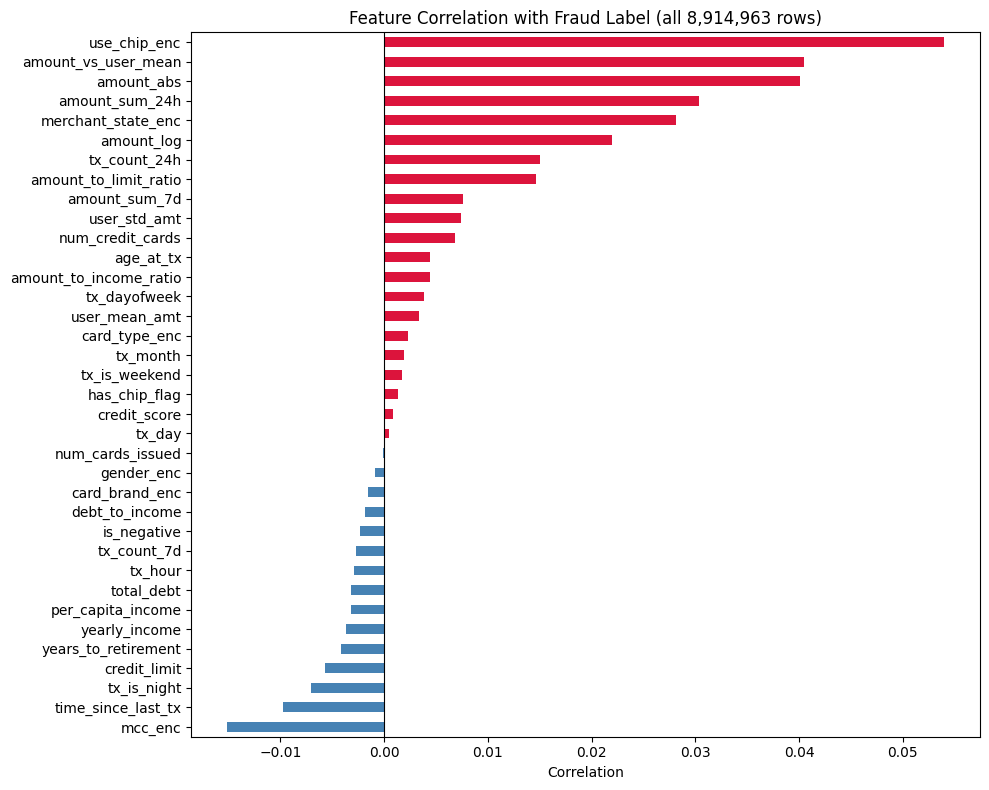

Top 5 positively correlated with fraud:
use_chip_enc           0.0540
amount_vs_user_mean    0.0405
amount_abs             0.0401
amount_sum_24h         0.0303
merchant_state_enc     0.0281
dtype: float64

Top 5 negatively correlated:
years_to_retirement   -0.0042
credit_limit          -0.0057
tx_is_night           -0.0071
time_since_last_tx    -0.0097
mcc_enc               -0.0151
dtype: float64


In [11]:
fraud_corr = X.drop(columns=['tx_year']).corrwith(y).dropna().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
fraud_corr.plot(kind='barh', color=fraud_corr.map(lambda v: 'crimson' if v > 0 else 'steelblue'))
plt.title(f'Feature Correlation with Fraud Label (all {len(X):,} rows)')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 positively correlated with fraud:')
print(fraud_corr.head(5).round(4))
print('\nTop 5 negatively correlated:')
print(fraud_corr.tail(5).round(4))

## Notes for Notebook 3

All features here are **causal** - safe for any time-based split. NB3 uses:
- Train: years < 2017
- Val  : year = 2017   (Optuna tuning + threshold selection + MLP early stopping)
- Test : years >= 2018 (touched exactly once at the end)

`tx_year` rides along in features.csv only to enable that split.